In [ ]:
import pickle

# change to your own data path
prefix = 'data/lba/'
# a list of rdkit mols
all_data = pickle.load(open(f'{prefix}/train_mols.pkl', 'rb'))

print(len(all_data), all_data[0])

3507 <rdkit.Chem.rdchem.Mol object at 0x7fc0db7ccf90>


# Build Vocab

In [ ]:
from rdkit import Chem
from tqdm import tqdm
from graph import HyperGraph
import numpy as np

# when ISOMERIC is False, stereochemical information and chirality are discarded.
# turn this to True if you want to keep chirality-aware tokens.
ISOMERIC = False

rdkit version 2023.09.4 >= 2023.09.4, using GetSymmSSSR


In [3]:
hyper_graphs = []

# convert mols to atom-bond graphs
for idx, mol in enumerate(tqdm(all_data)):
    smiles = Chem.MolToSmiles(mol, kekuleSmiles=False, isomericSmiles=ISOMERIC)
    hyper_g = HyperGraph(mol, idx, smiles, isomeric=ISOMERIC)
    # discover bonds and rings
    hyper_g.contract_basic_tokens()
    # check all atoms are covered
    hyper_g.check_coverage()
    hyper_graphs.append(hyper_g)

100%|██████████| 3507/3507 [00:26<00:00, 130.80it/s]


Find all possible basic tokens and count frequency. Basic tokens include: atoms, bonds, rings. Use ``show_vocab_2d`` to display the tokens.

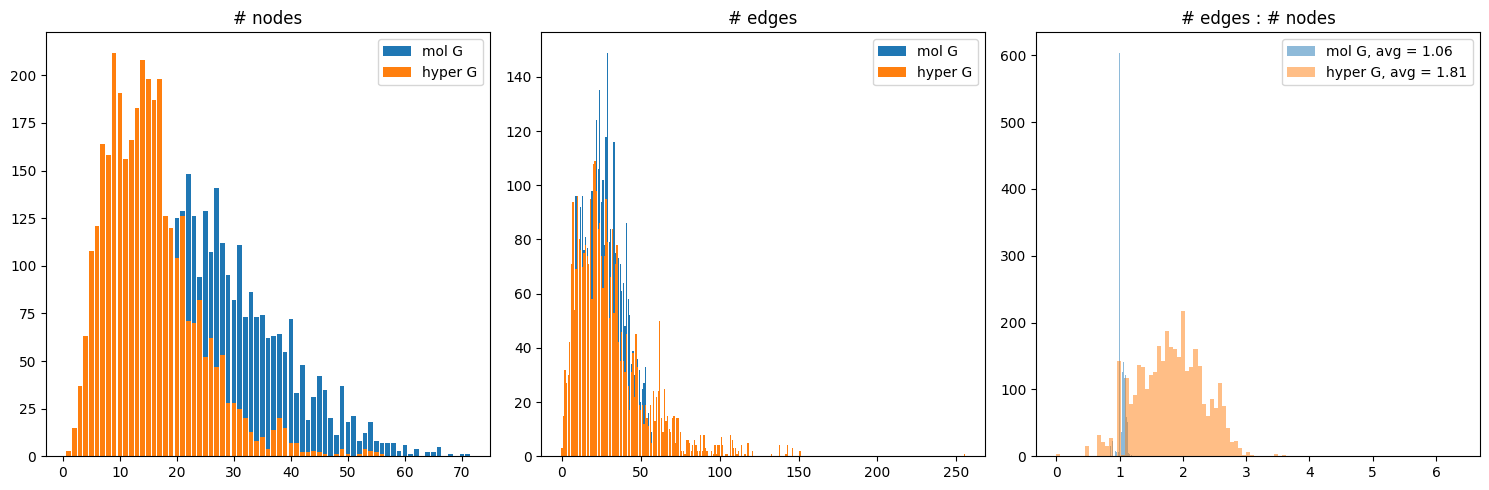

# atoms: 15


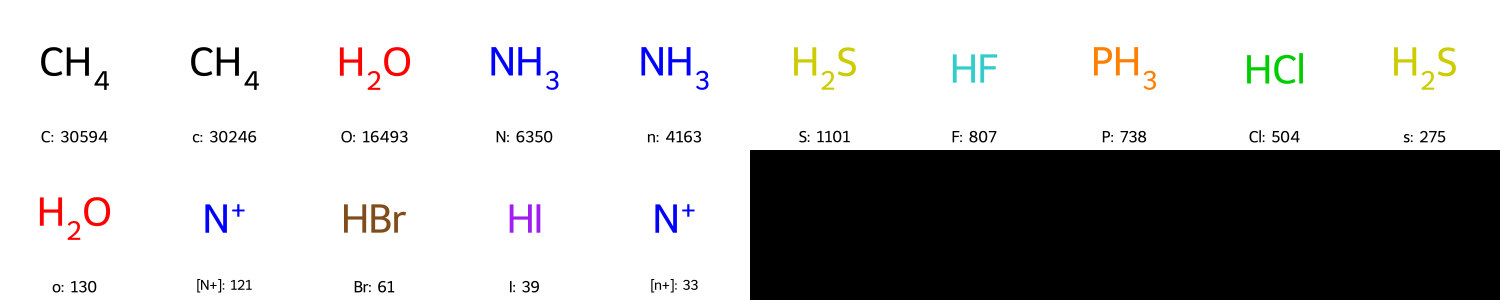

# bonds: 64
# aromatic rings: 59
# non-aromatic rings: 214


In [4]:
from vocab_utils import plot_init_node_edge_num

# display the initial number of atoms and edges
plot_init_node_edge_num(hyper_graphs)

from vocab_utils import count_atom_freq, count_basic_token_freq, show_vocab_2d, count_hyper_pair_freq

# count the frequency of unique atoms
atom_freq = count_atom_freq(hyper_graphs)
print('# atoms:', len(atom_freq))

# display the unique atoms (charge and aromaticity are considered)
show_vocab_2d(atom_freq)

# basic tokens include all atoms, frequent bonds and rings
bond_freq, aromatic_ring_freq, non_aromatic_ring_freq = count_basic_token_freq(hyper_graphs)
print('# bonds:', len(bond_freq))
print('# aromatic rings:', len(aromatic_ring_freq))
print('# non-aromatic rings:', len(non_aromatic_ring_freq))

# you can also display the unique bonds, aromatic rings, and non-aromatic rings
# show_vocab_2d(bond_freq)
# show_vocab_2d(aromatic_ring_freq)
# show_vocab_2d(non_aromatic_ring_freq)

Show frequency distribution to help determine frequency threshold.

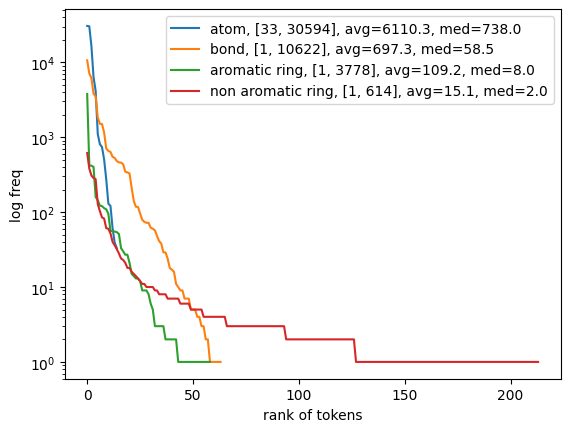

In [5]:
from collections import Counter
import matplotlib.pyplot as plt

af = [v for k, v in atom_freq.most_common()]
bf = [v for k, v in bond_freq.most_common()]
arf = [v for k, v in aromatic_ring_freq.most_common()]
nrf = [v for k, v in non_aromatic_ring_freq.most_common()]
plt.plot(range(len(af)), af, label=f'atom, [{min(af)}, {max(af)}], avg={sum(af) / len(af):.1f}, med={np.median(af):.1f}')
plt.plot(range(len(bf)), bf, label=f'bond, [{min(bf)}, {max(bf)}], avg={sum(bf) / len(bf):.1f}, med={np.median(bf):.1f}')
plt.plot(range(len(arf)), arf, label=f'aromatic ring, [{min(arf)}, {max(arf)}], avg={sum(arf) / len(arf):.1f}, med={np.median(arf):.1f}')
plt.plot(range(len(nrf)), nrf, label=f'non aromatic ring, [{min(nrf)}, {max(nrf)}], avg={sum(nrf) / len(nrf):.1f}, med={np.median(nrf):.1f}')
plt.yscale('log')
plt.xlabel('rank of tokens')
plt.ylabel('log freq')
plt.legend()
plt.show()

Find at most 400 composite tokens through BPE. We will do frequency filtering on these results. Change the size if you have a much larger molecule library. This block will run around 2min with 1 CPU on LBA.

In [6]:
vocab = {}
MAX_VOCAB_SIZE = 400

"""
greedy search for composite tokens through merging neighboring tokens
takes ~ 2 minutes to greedy search 400 composite tokens
"""
for i in range(MAX_VOCAB_SIZE):
    print('-' * 30, f'current vocab size: {len(vocab)}', '-' * 30)
    smiles_counter = count_hyper_pair_freq(hyper_graphs)
    print(smiles_counter.most_common(10))
    candidate = smiles_counter.most_common(1)[0]
    print('contracting', candidate)
    vocab[candidate[0]] = candidate[1]
    affected = []
    for idx, hyper_g in enumerate(tqdm(hyper_graphs)):
        flag = hyper_g.contract_hyper_pair(candidate[0], sharing_hyper_node=True)
        if flag:
            hyper_g.check_coverage()
            affected.append(idx)

    print(len(affected), 'affected!', len(affected) / len(hyper_graphs), '\n')

------------------------------ current vocab size: 0 ------------------------------
[('CCC', 6356), ('CCN', 4648), ('CCO', 3735), ('CCNC', 3345), ('CCCC', 3021), ('CCCN', 2618), ('Cc1ccccc1', 2458), ('CC=O', 2303), ('NC=O', 2219), ('CNC', 2128)]
contracting ('CCC', 6356)


  0%|          | 0/3507 [00:00<?, ?it/s]

100%|██████████| 3507/3507 [00:10<00:00, 347.43it/s]


1509 affected! 0.43028229255774164 

------------------------------ current vocab size: 1 ------------------------------
[('CCCC', 3021), ('CCCN', 2618), ('CC(C)C', 2484), ('Cc1ccccc1', 2458), ('NC=O', 2219), ('CNC', 2128), ('CCCNC', 1956), ('CCCO', 1670), ('CCC=O', 1523), ('O=[PH]=O', 1487)]
contracting ('CCCC', 3021)


100%|██████████| 3507/3507 [00:06<00:00, 502.22it/s]


...

14 affected! 0.003992015968063872 

------------------------------ current vocab size: 398 ------------------------------
[('c-c1ccc(S(N)(=O)=O)cc1', 14), ('Cc1nccs1', 14), ('Cc1ccccc1Cl', 14), ('cNC(=O)c1cccc(CN2C(=O)NCCC(O)C2Cc2ccccc2)c1', 13), ('Cn1ccc[nH]c1', 13), ('c-n1cccc1', 13), ('CCC(O)CC(O)CC', 13), ('cNc1ncc(C(=O)Nc2c(C)cccc2Cl)s1', 13), ('NS(=O)(=O)c1ccc(C(=O)NCc2ccccc2F)cc1', 13), ('CC(=O)NO', 13)]
contracting ('c-c1ccc(S(N)(=O)=O)cc1', 14)


100%|██████████| 3507/3507 [00:00<00:00, 187214.26it/s]


14 affected! 0.003992015968063872 

------------------------------ current vocab size: 399 ------------------------------
[('Cc1nccs1', 14), ('Cc1ccccc1Cl', 14), ('cNC(=O)c1cccc(CN2C(=O)NCCC(O)C2Cc2ccccc2)c1', 13), ('Cn1ccc[nH]c1', 13), ('c-n1cccc1', 13), ('CCC(O)CC(O)CC', 13), ('cNc1ncc(C(=O)Nc2c(C)cccc2Cl)s1', 13), ('NS(=O)(=O)c1ccc(C(=O)NCc2ccccc2F)cc1', 13), ('CC(=O)NO', 13), ('CC(=O)NS(C)(=O)=O', 13)]
contracting ('Cc1nccs1', 14)


100%|██████████| 3507/3507 [00:00<00:00, 68411.79it/s]

13 affected! 0.0037068719703450244 



total # composite tokens: 400
token freq larger than the previous one:


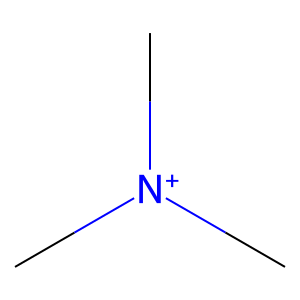

56 C[N+](C)C 321


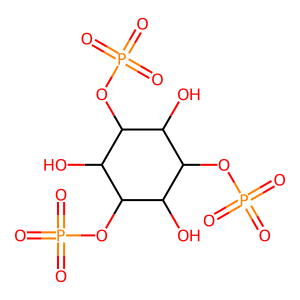

149 O=P(=O)(=O)OC1C(O)C(OP(=O)(=O)=O)C(O)C(OP(=O)(=O)=O)C1O 54


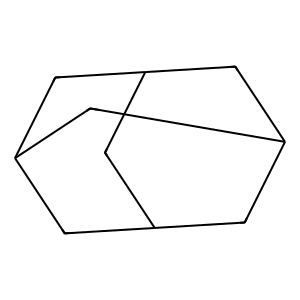

158 C1C2CC3CC1CC(C2)C3 105


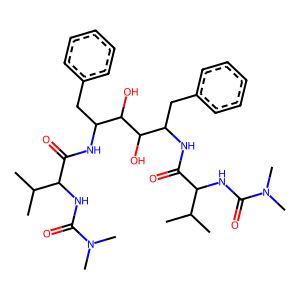

340 CC(C)C(NC(=O)N(C)C)C(=O)NC(Cc1ccccc1)C(O)C(O)C(Cc1ccccc1)NC(=O)C(NC(=O)N(C)C)C(C)C 24
last item in vocab:


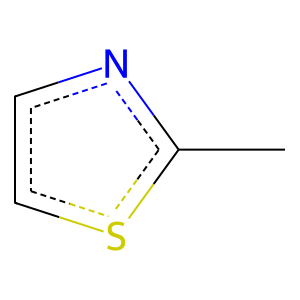

('Cc1nccs1', 14)


In [7]:
print('total # composite tokens:', len(vocab))
from display_utils import show_2d_smiles

"""
Since we adopt greedy search, different token pairs may merge into the same composite token, 
leading to an increased frequency of that composite token. 
Such composite tokens typically correspond to highly symmetric structures.
"""
print('token freq larger than the previous one:')
last_freq = 1e10
last_item = None
for idx, (k, v) in enumerate(vocab.items()):
    if v > last_freq:
        show_2d_smiles(k)
        print(idx, k, v)
    last_freq = v
    last_item = (k, v)

print('last item in vocab:')
# show last item in vocab
show_2d_smiles(last_item[0])
print(last_item)


In [ ]:
# display all discovered composite tokens: graph, smiles, and freq
show_vocab_2d(vocab)

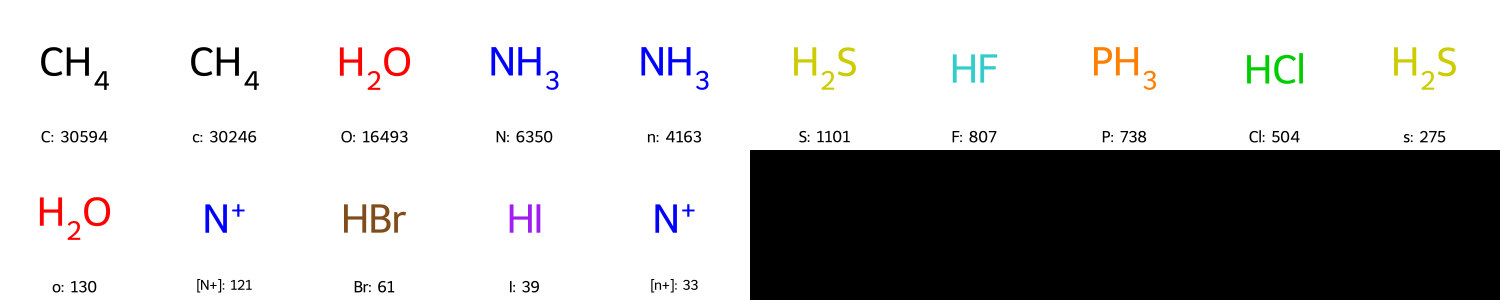

------------------------------ min_freq: 50 ------------------------------
current vocab size: 213



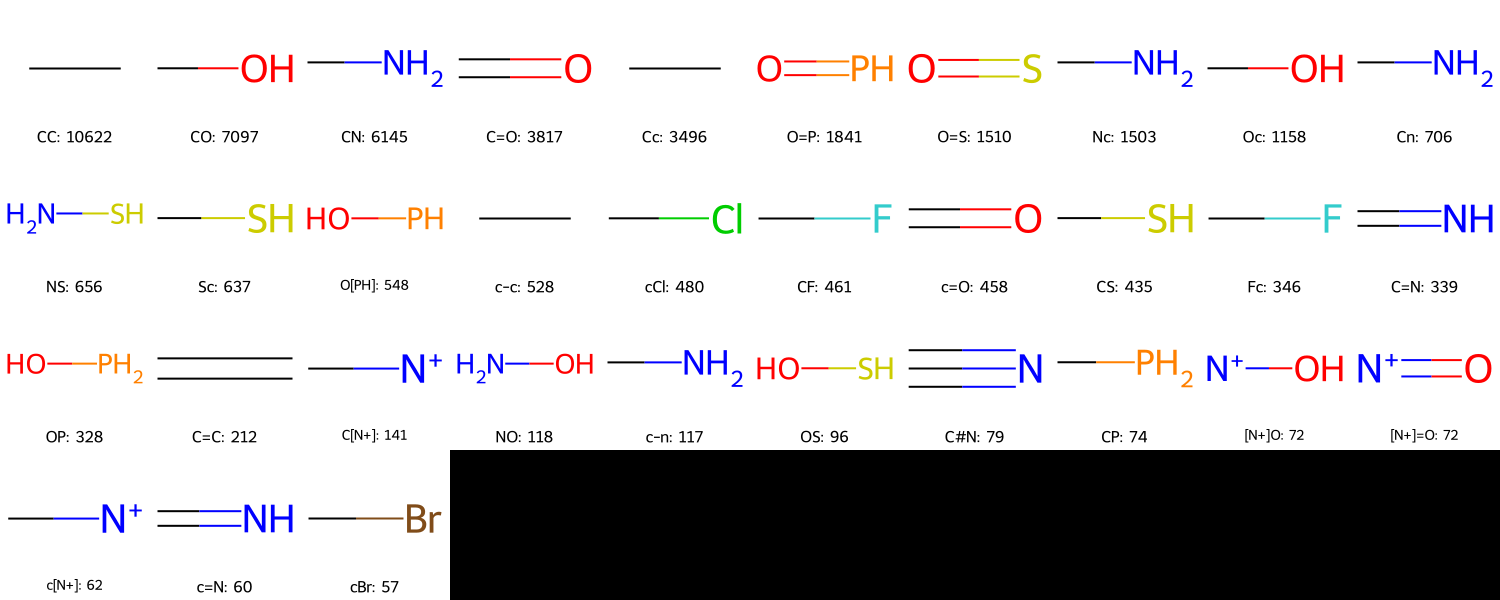

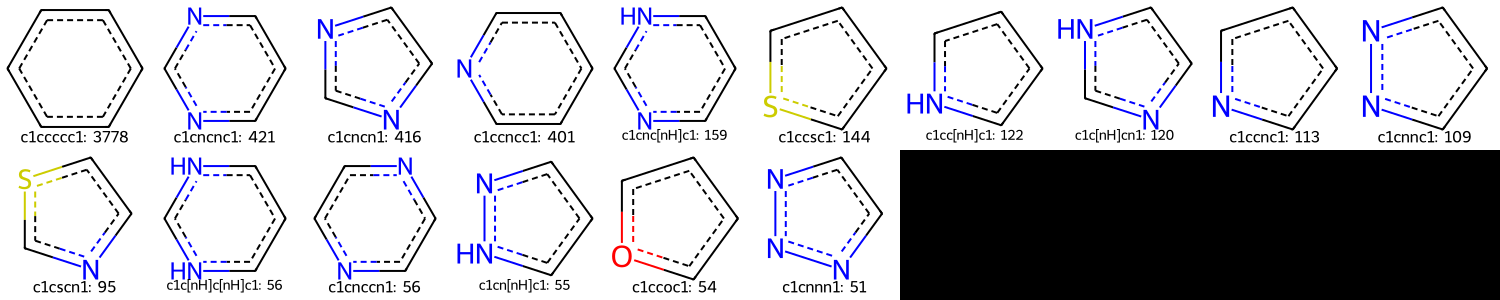

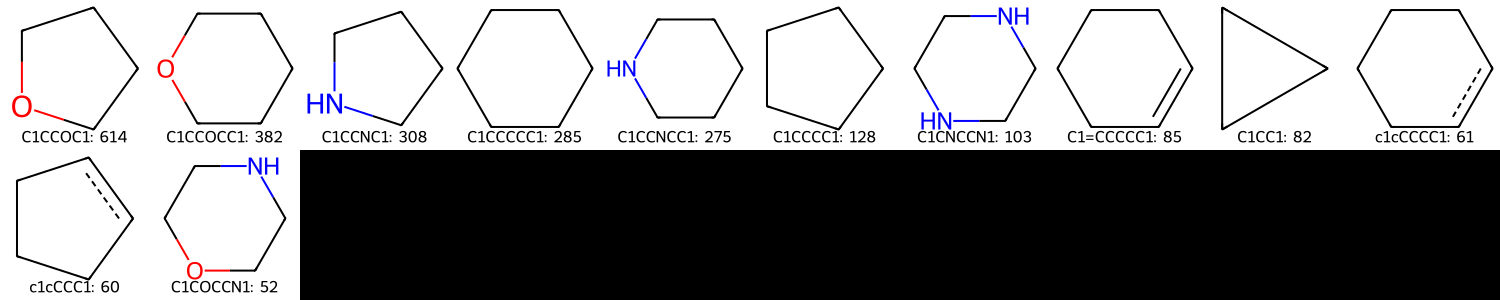

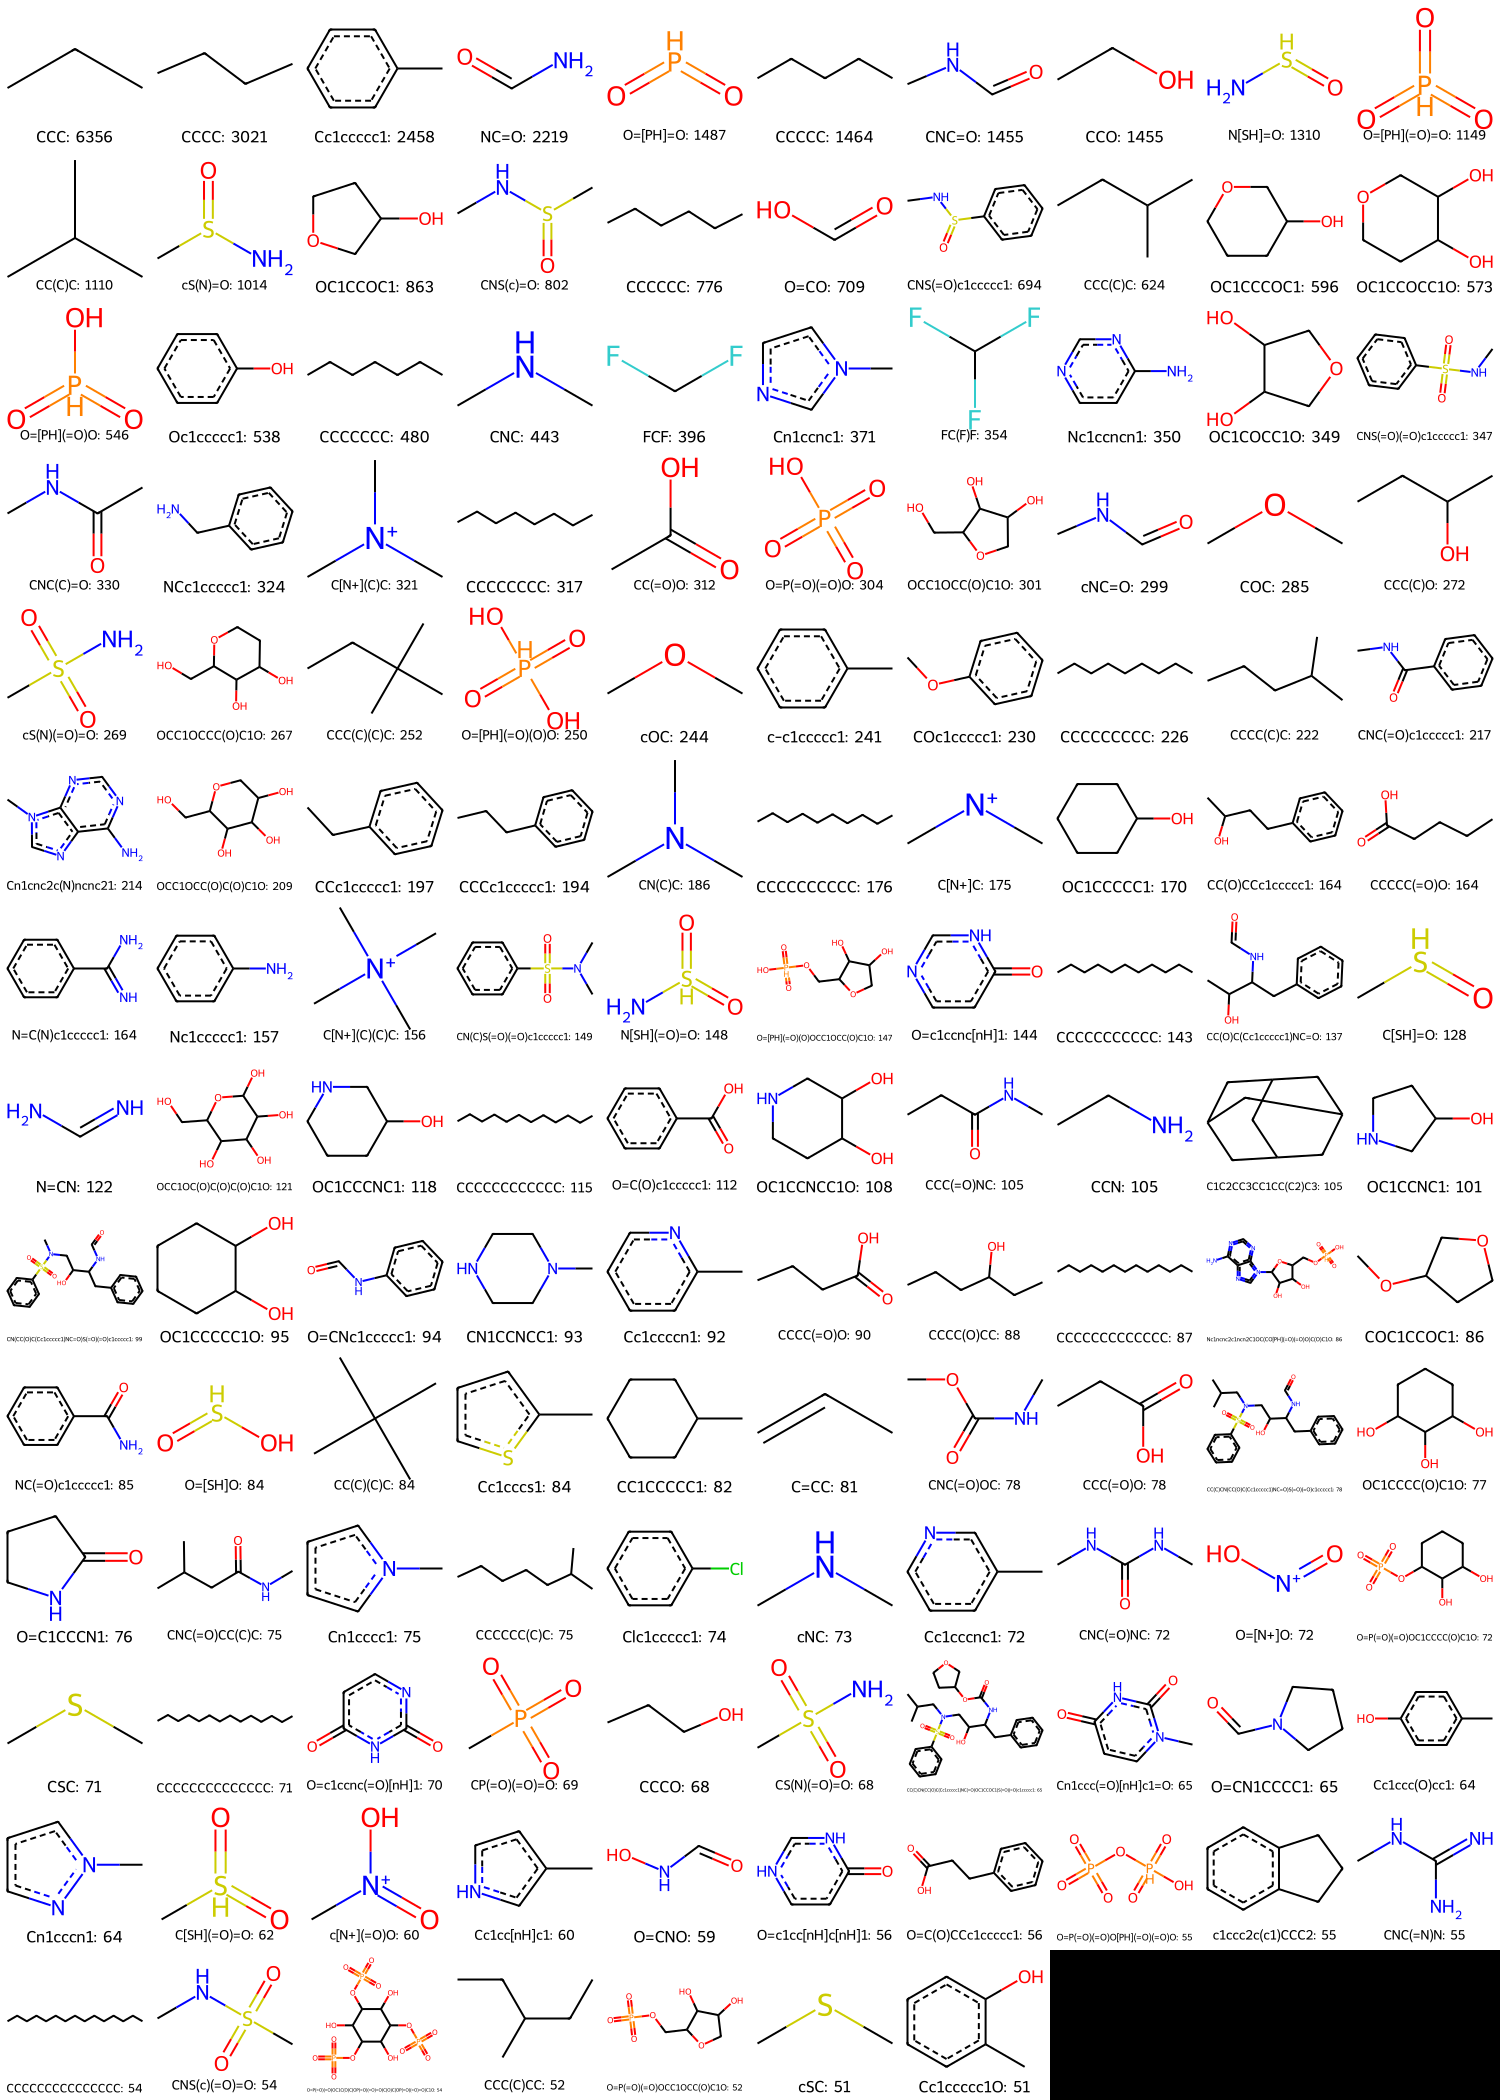

In [9]:
# preserve all atom tokens
atom_vocab = {}
for smiles, freq in atom_freq.most_common():
    atom_vocab[smiles] = freq
show_vocab_2d(atom_vocab)

from collections import Counter

# add bond, aromatic ring, non-aromatic ring, and composite tokens to final vocab
def get_vocab_by_freq(bond_freq: Counter, aromatic_ring_freq: Counter, non_aromatic_ring_freq: Counter, hyper_vocab: dict, min_freq: int = 50):
    print('-' * 30, f'min_freq: {min_freq}', '-' * 30)
    bond_vocab = {}
    aromatic_ring_vocab = {}
    non_aromatic_ring_vocab = {}

    for smiles, freq in bond_freq.most_common():
        if freq > min_freq:
            bond_vocab[smiles] = freq

    for smiles, freq in aromatic_ring_freq.most_common():
        if freq > min_freq:
            aromatic_ring_vocab[smiles] = freq

    for smiles, freq in non_aromatic_ring_freq.most_common():
        if freq > min_freq:
            non_aromatic_ring_vocab[smiles] = freq

    hyper_token_vocab = {}
    for k, v in Counter(hyper_vocab).most_common():
        if v > min_freq:
            hyper_token_vocab[k] = v
    
    vocab_size = len(atom_vocab) + len(bond_vocab) + len(aromatic_ring_vocab) + len(non_aromatic_ring_vocab) + len(hyper_token_vocab)
    print(f'current vocab size: {vocab_size}\n')
    show_vocab_2d(bond_vocab)
    show_vocab_2d(aromatic_ring_vocab)
    show_vocab_2d(non_aromatic_ring_vocab)
    show_vocab_2d(hyper_token_vocab)
    full_vocab = {
        'atom_vocab': atom_vocab,
        'bond_vocab': bond_vocab,
        'aromatic_ring_vocab': aromatic_ring_vocab,
        'non_aromatic_ring_vocab': non_aromatic_ring_vocab,
        'hyper_token_vocab': hyper_token_vocab
    }
    if ISOMERIC:
        pickle.dump(full_vocab, open(f'{prefix}/vocab_iso_{vocab_size}.pkl', 'wb'))
    else:
        pickle.dump(full_vocab, open(f'{prefix}/vocab_{vocab_size}.pkl', 'wb'))

# pass min_freq to filter out low-frequency tokens and control the size of final vocab
get_vocab_by_freq(bond_freq, aromatic_ring_freq, non_aromatic_ring_freq, vocab, min_freq=50)

# Tokenization (Optional)

After obtaining the vocab, here we shouw how to tokenize a new molecule.

In [1]:
import pickle

prefix = 'data/lba/'
all_data = pickle.load(open(f'{prefix}/train_mols.pkl', 'rb'))

print(len(all_data), all_data[0])

3507 <rdkit.Chem.rdchem.Mol object at 0x7f44e0a977c0>


In [2]:
from tqdm import tqdm
from rdkit import Chem
from graph import HyperGraph
from tokenizer import MergeTokenizer

vocab_path = f'{prefix}/vocab_213.pkl'
tokenizer = MergeTokenizer(vocab_path)

rdkit version 2023.09.4 >= 2023.09.4, using GetSymmSSSR


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

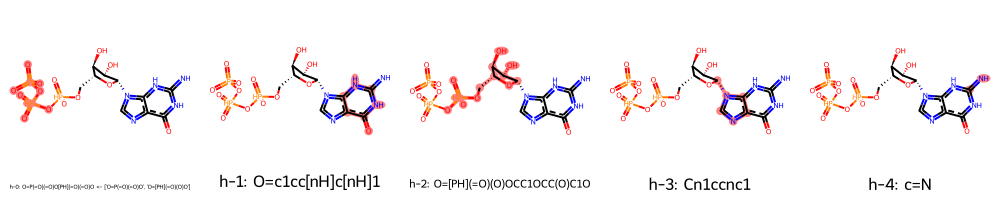

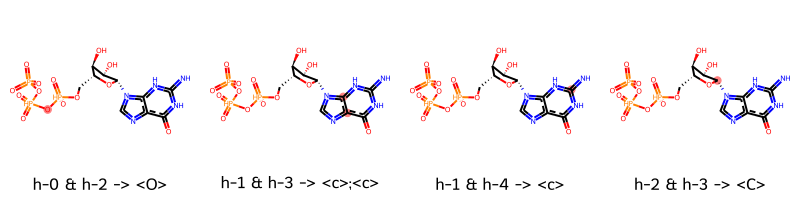

In [ ]:
from display_utils import show_3d_mol

# display tokenization result for 1 molecule
ISOMERIC = False
idx = 1
mol = all_data[idx]
show_3d_mol(mol)
smiles = Chem.MolToSmiles(mol, kekuleSmiles=False, isomericSmiles=ISOMERIC)
hg = tokenizer.tokenize(mol, idx, smiles)
hg.check_coverage()
hg.show_tokenization()

This block runs around 1min20s with 1 CPU on LBA training set.

In [4]:
from tqdm import tqdm

hyper_graphs = []

for idx, mol in enumerate(tqdm(all_data)):
    smiles = Chem.MolToSmiles(mol, kekuleSmiles=False, isomericSmiles=ISOMERIC)
    hg = tokenizer.tokenize(mol, idx, smiles)
    hg.check_coverage()
    hyper_graphs.append(hg)

# save hyper_graphs
# pickle.dump(hyper_graphs, open(f'{prefix}/train_hyper_graphs.pkl', 'wb'))


  0%|          | 0/3507 [00:00<?, ?it/s]

100%|██████████| 3507/3507 [01:20<00:00, 43.43it/s]
